# 난지 시간별 데이터 신뢰도 검증

목적:

- 현재 사용 중인 난지 시간별 통합 데이터가 일별 원본을 얼마나 일관되게 반영하는지 확인
- 단순 컬럼 복사 수준의 일치와, 시간별로 분해된 값의 재집계 일치 여부를 구분해서 검증
- 상관계수와 오차, 시각화를 통해 시간별 데이터의 신뢰도를 판단

주의:

- 이 검증은 외부 실측 시간 로그와의 비교가 아니라, **같은 일별 원본에서 만들어진 시간별 데이터의 내적 일관성 검증**입니다.
- 따라서 상관이 매우 높게 나오더라도, 이것은 "실제 시간별 주차 상태를 정확히 측정했다"는 뜻이 아니라, "일별 원본 총량을 시간축으로 일관되게 재구성했다"는 의미로 해석해야 합니다.


In [1]:
%matplotlib inline

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import koreanize_matplotlib  # noqa: F401
except Exception:
    pass

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
ROOT = next(
    path for path in [cwd, *cwd.parents]
    if (path / "ksm").exists() and (path / "hmw").exists()
)
HOURLY_PATH = ROOT / "ksm/nanji_hourly_modeling/nanji_hourly_model_dataset_2020_2026.csv"
RAW_DAILY_PATH = ROOT / "hmw/Data/한강공원 주차장 일별 이용 현황.csv"

print("ROOT:", ROOT)
print("HOURLY_PATH:", HOURLY_PATH)
print("RAW_DAILY_PATH:", RAW_DAILY_PATH)



ROOT: /Users/electrozone/Documents/nanji_work
HOURLY_PATH: /Users/electrozone/Documents/nanji_work/ksm/nanji_hourly_modeling/nanji_hourly_model_dataset_2020_2026.csv
RAW_DAILY_PATH: /Users/electrozone/Documents/nanji_work/hmw/Data/한강공원 주차장 일별 이용 현황.csv


## 1. 데이터 불러오기와 비교 기준 만들기

비교 방식:

1. 원본 일별 데이터에서 난지 주차장만 집계
2. 시간별 통합 데이터에서 날짜별로 다시 집계
3. 아래 항목을 비교
   - 일별 `주차대수`
   - 일별 `이용시간`
   - `estimated_entries` 일별 합계
   - `estimated_active_cars` 일별 합계 x 60분

여기서 `estimated_active_cars`의 일별 합계에 `60`을 곱한 값은 시간 적분 관점에서 하루 총 체류 분(minutes)에 대응하므로, 원본 일별 `이용시간`과 비교할 수 있습니다.


In [2]:
hourly_df = pd.read_csv(HOURLY_PATH, parse_dates=["datetime", "date"])
hourly_df = hourly_df[hourly_df["year"].between(2022, 2025)].copy()

raw_daily_df = pd.read_csv(RAW_DAILY_PATH, encoding="cp949")
raw_daily_df["날짜"] = pd.to_datetime(raw_daily_df["날짜"])
raw_daily_df = raw_daily_df[raw_daily_df["주차장명"].astype(str).str.contains("난지", na=False)].copy()
raw_daily_df = raw_daily_df[raw_daily_df["날짜"].dt.year.between(2022, 2025)].copy()

raw_daily = (
    raw_daily_df.groupby("날짜", as_index=False)
    .agg(
        raw_daily_parking_count=("주차대수", "sum"),
        raw_daily_usage_minutes=("이용시간", "sum"),
    )
    .sort_values("날짜")
    .reset_index(drop=True)
)
raw_daily["raw_avg_stay_minutes"] = (
    raw_daily["raw_daily_usage_minutes"]
    / raw_daily["raw_daily_parking_count"].replace(0, np.nan)
)

hourly_daily = (
    hourly_df.groupby("date", as_index=False)
    .agg(
        daily_parking_count=("daily_parking_count", "first"),
        daily_usage_minutes=("daily_usage_minutes", "first"),
        avg_stay_minutes=("avg_stay_minutes", "first"),
        estimated_entries_sum=("estimated_entries", "sum"),
        estimated_active_sum=("estimated_active_cars", "sum"),
        estimated_active_max=("estimated_active_cars", "max"),
        hourly_share_sum=("hourly_share", "sum"),
        active_nonzero_hours=("estimated_active_cars", lambda s: int((s > 0).sum())),
    )
    .sort_values("date")
    .reset_index(drop=True)
)

merged = raw_daily.merge(hourly_daily, left_on="날짜", right_on="date", how="inner")
merged["active_minutes_from_hourly"] = merged["estimated_active_sum"] * 60.0
merged["entries_abs_error"] = (merged["estimated_entries_sum"] - merged["raw_daily_parking_count"]).abs()
merged["usage_gap_minutes"] = merged["active_minutes_from_hourly"] - merged["raw_daily_usage_minutes"]
merged["usage_abs_error"] = merged["usage_gap_minutes"].abs()
merged["usage_ape"] = merged["usage_abs_error"] / merged["raw_daily_usage_minutes"].replace(0, np.nan)

summary_df = pd.DataFrame([
    {
        "comparison": "원본 일별 주차대수 vs 시간별 데이터 내 daily_parking_count",
        "pearson_r": merged["raw_daily_parking_count"].corr(merged["daily_parking_count"]),
        "spearman_r": merged["raw_daily_parking_count"].corr(merged["daily_parking_count"], method="spearman"),
        "mae": merged["raw_daily_parking_count"].sub(merged["daily_parking_count"]).abs().mean(),
        "max_abs_error": merged["raw_daily_parking_count"].sub(merged["daily_parking_count"]).abs().max(),
    },
    {
        "comparison": "원본 일별 이용시간 vs 시간별 데이터 내 daily_usage_minutes",
        "pearson_r": merged["raw_daily_usage_minutes"].corr(merged["daily_usage_minutes"]),
        "spearman_r": merged["raw_daily_usage_minutes"].corr(merged["daily_usage_minutes"], method="spearman"),
        "mae": merged["raw_daily_usage_minutes"].sub(merged["daily_usage_minutes"]).abs().mean(),
        "max_abs_error": merged["raw_daily_usage_minutes"].sub(merged["daily_usage_minutes"]).abs().max(),
    },
    {
        "comparison": "원본 일별 주차대수 vs 시간별 추정 유입 합계(estimated_entries_sum)",
        "pearson_r": merged["raw_daily_parking_count"].corr(merged["estimated_entries_sum"]),
        "spearman_r": merged["raw_daily_parking_count"].corr(merged["estimated_entries_sum"], method="spearman"),
        "mae": merged["entries_abs_error"].mean(),
        "max_abs_error": merged["entries_abs_error"].max(),
    },
    {
        "comparison": "원본 일별 이용시간 vs 시간 적분 점유량(estimated_active_cars sum x 60)",
        "pearson_r": merged["raw_daily_usage_minutes"].corr(merged["active_minutes_from_hourly"]),
        "spearman_r": merged["raw_daily_usage_minutes"].corr(merged["active_minutes_from_hourly"], method="spearman"),
        "mae": merged["usage_abs_error"].mean(),
        "max_abs_error": merged["usage_abs_error"].max(),
    },
    {
        "comparison": "원본 일별 이용시간 vs 시간별 최대 점유량(estimated_active_max)",
        "pearson_r": merged["raw_daily_usage_minutes"].corr(merged["estimated_active_max"]),
        "spearman_r": merged["raw_daily_usage_minutes"].corr(merged["estimated_active_max"], method="spearman"),
        "mae": np.nan,
        "max_abs_error": np.nan,
    },
])

display(pd.DataFrame({
    "metric": ["비교 가능한 날짜 수", "원본 일별 데이터 시작", "원본 일별 데이터 종료", "시간별 데이터 시작", "시간별 데이터 종료"],
    "value": [len(merged), raw_daily["날짜"].min(), raw_daily["날짜"].max(), hourly_df["datetime"].min(), hourly_df["datetime"].max()],
}))
display(summary_df)
display(merged[["날짜", "raw_daily_parking_count", "estimated_entries_sum", "raw_daily_usage_minutes", "active_minutes_from_hourly", "usage_gap_minutes"]].head())


,metric,value
0,비교 가능한 날짜 수,1455
1,원본 일별 데이터 시작,2022-01-01 00:00:00
2,원본 일별 데이터 종료,2025-12-31 00:00:00
3,시간별 데이터 시작,2022-01-01 00:00:00
4,시간별 데이터 종료,2025-12-31 23:00:00


,comparison,pearson_r,spearman_r,mae,max_abs_error
0,원본 일별 주차대수 vs 시간별 데이터 내 daily_parking_count,1.000000,1.000000,0.000000e+00,0.000000e+00
1,원본 일별 이용시간 vs 시간별 데이터 내 daily_usage_minutes,1.000000,1.000000,0.000000e+00,0.000000e+00
2,원본 일별 주차대수 vs 시간별 추정 유입 합계(estimated_entries_sum),1.000000,1.000000,1.322635e-13,9.094947e-13
3,원본 일별 이용시간 vs 시간 적분 점유량(estimated_active_cars ...,0.999974,0.999997,3.094973e+02,9.555000e+03
4,원본 일별 이용시간 vs 시간별 최대 점유량(estimated_active_max),0.996369,0.994819,NaN,NaN


,날짜,raw_daily_parking_count,estimated_entries_sum,raw_daily_usage_minutes,active_minutes_from_hourly,usage_gap_minutes
0,2022-01-01,1167,1167.0,53123,53123.0,7.275958e-12
1,2022-01-02,939,939.0,47775,47775.0,7.275958e-12
2,2022-01-03,982,982.0,38073,38073.0,7.275958e-12
3,2022-01-04,829,829.0,32796,32796.0,0.000000e+00
4,2022-01-05,858,858.0,40224,40224.0,7.275958e-12


## 2. 수치 해석

핵심 해석 포인트:

- `daily_parking_count`, `daily_usage_minutes`, `avg_stay_minutes`는 시간별 통합 데이터 안에 원본 일별 값이 그대로 반영된 컬럼이라 사실상 완전 일치가 나와야 합니다.
- 더 중요한 검증은 `estimated_entries`의 일별 합계와 `estimated_active_cars`의 시간 적분값이 원본 일별 총량을 얼마나 잘 복원하는지입니다.
- `estimated_entries_sum`이 일별 `주차대수`와 거의 완전히 일치하면, 시간 배분(`hourly_share`)이 총량 보존 관점에서 일관적이라는 뜻입니다.
- `estimated_active_cars sum x 60`이 일별 `이용시간`과 매우 높게 맞으면, 평균 체류시간을 이용한 점유 추정이 일별 체류 총량을 상당히 잘 보존한다는 뜻입니다.
- 다만 이것은 같은 원본에서 파생된 데이터끼리의 비교이므로, **실제 시간별 운영 상황을 외부 독립 데이터로 검증한 것은 아닙니다.**


In [3]:
reliability_note = pd.DataFrame([
    {
        "판단 항목": "총량 보존(주차대수)",
        "판단": "매우 높음",
        "근거": f"estimated_entries 일별 합계와 원본 일별 주차대수의 Pearson r = {merged['raw_daily_parking_count'].corr(merged['estimated_entries_sum']):.6f}, 최대 절대오차 = {merged['entries_abs_error'].max():.6g}",
    },
    {
        "판단 항목": "총량 보존(이용시간)",
        "판단": "매우 높음",
        "근거": f"estimated_active_cars 적분값과 원본 일별 이용시간의 Pearson r = {merged['raw_daily_usage_minutes'].corr(merged['active_minutes_from_hourly']):.6f}, 중위 절대오차 = {merged['usage_abs_error'].median():.6g}분",
    },
    {
        "판단 항목": "예외 날짜 존재 여부",
        "판단": "주의 필요",
        "근거": f"저이용 또는 원본 이용시간이 0에 가까운 일부 날짜에서 상대오차가 크게 튐. 원본 이용시간 0일은 {(merged['raw_daily_usage_minutes'] == 0).sum()}일",
    },
    {
        "판단 항목": "최종 신뢰도 판단",
        "판단": "내적 일관성 높음",
        "근거": "일별 총량과 체류 총시간을 거의 그대로 복원하므로 학습용 추정 데이터로는 신뢰할 수 있으나, 독립적인 실측 시간 로그 검증은 별도로 필요",
    },
])

display(reliability_note)


,판단 항목,판단,근거
0,총량 보존(주차대수),매우 높음,estimated_entries 일별 합계와 원본 일별 주차대수의 Pearson r...
1,총량 보존(이용시간),매우 높음,estimated_active_cars 적분값과 원본 일별 이용시간의 Pearson...
2,예외 날짜 존재 여부,주의 필요,저이용 또는 원본 이용시간이 0에 가까운 일부 날짜에서 상대오차가 크게 튐. 원본 ...
3,최종 신뢰도 판단,내적 일관성 높음,일별 총량과 체류 총시간을 거의 그대로 복원하므로 학습용 추정 데이터로는 신뢰할 수...


## 3. 시각화

그래프는 아래 네 가지를 봅니다.

1. 일별 `주차대수`: 원본 vs 시간별 재집계
2. 일별 `이용시간`: 원본 vs 시간 적분 점유량
3. 산점도: 상관 구조 확인
4. 이용시간 오차 분포: 예외 날짜가 얼마나 있는지 확인


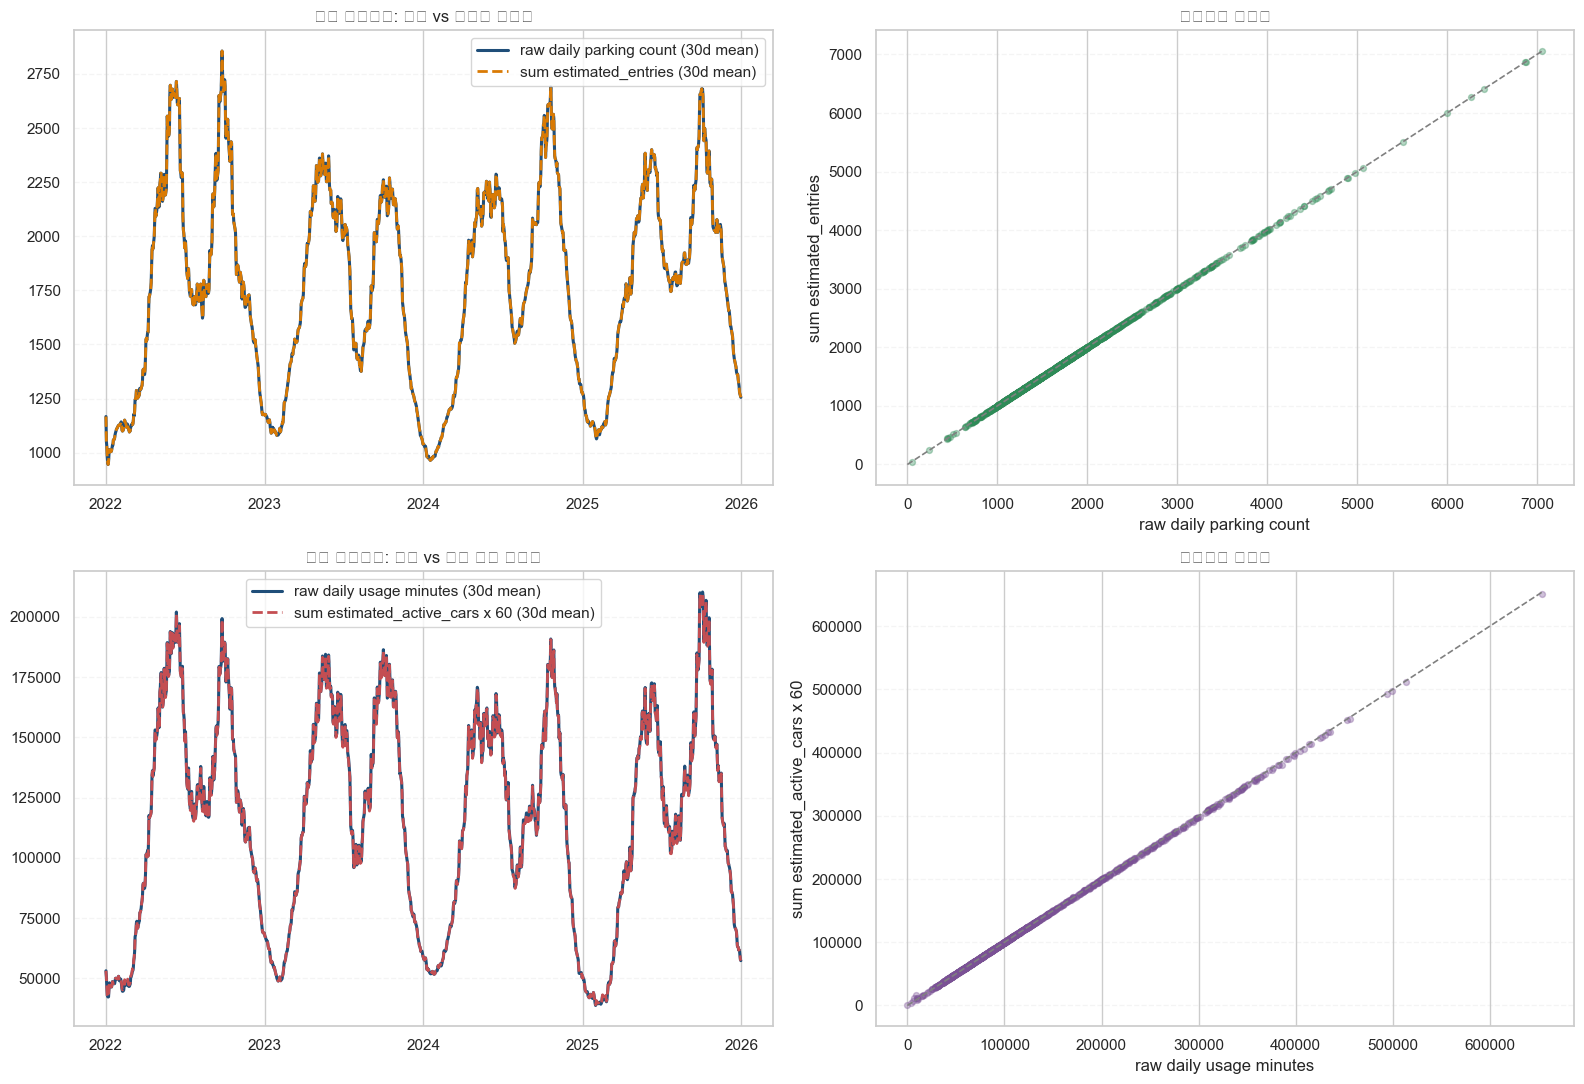

In [4]:
plot_df = merged.copy()
plot_df["parking_count_roll30_raw"] = plot_df["raw_daily_parking_count"].rolling(30, min_periods=1).mean()
plot_df["parking_count_roll30_hourly"] = plot_df["estimated_entries_sum"].rolling(30, min_periods=1).mean()
plot_df["usage_roll30_raw"] = plot_df["raw_daily_usage_minutes"].rolling(30, min_periods=1).mean()
plot_df["usage_roll30_hourly"] = plot_df["active_minutes_from_hourly"].rolling(30, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0, 0].plot(plot_df["날짜"], plot_df["parking_count_roll30_raw"], label="raw daily parking count (30d mean)", linewidth=2.2, color="#1f4e79")
axes[0, 0].plot(plot_df["날짜"], plot_df["parking_count_roll30_hourly"], label="sum estimated_entries (30d mean)", linewidth=2.0, linestyle="--", color="#d97a04")
axes[0, 0].set_title("일별 주차대수: 원본 vs 시간별 재집계")
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0, 0].legend(frameon=True)

axes[0, 1].scatter(plot_df["raw_daily_parking_count"], plot_df["estimated_entries_sum"], alpha=0.35, s=18, color="#2e8b57")
line_max = max(plot_df["raw_daily_parking_count"].max(), plot_df["estimated_entries_sum"].max())
axes[0, 1].plot([0, line_max], [0, line_max], color="gray", linestyle="--", linewidth=1.2)
axes[0, 1].set_title("주차대수 산점도")
axes[0, 1].set_xlabel("raw daily parking count")
axes[0, 1].set_ylabel("sum estimated_entries")

axes[1, 0].plot(plot_df["날짜"], plot_df["usage_roll30_raw"], label="raw daily usage minutes (30d mean)", linewidth=2.2, color="#1f4e79")
axes[1, 0].plot(plot_df["날짜"], plot_df["usage_roll30_hourly"], label="sum estimated_active_cars x 60 (30d mean)", linewidth=2.0, linestyle="--", color="#c44e52")
axes[1, 0].set_title("일별 이용시간: 원본 vs 시간 적분 점유량")
axes[1, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1, 0].legend(frameon=True)

valid_usage = plot_df[plot_df["raw_daily_usage_minutes"] > 0].copy()
axes[1, 1].scatter(valid_usage["raw_daily_usage_minutes"], valid_usage["active_minutes_from_hourly"], alpha=0.35, s=18, color="#7a5195")
usage_max = max(valid_usage["raw_daily_usage_minutes"].max(), valid_usage["active_minutes_from_hourly"].max())
axes[1, 1].plot([0, usage_max], [0, usage_max], color="gray", linestyle="--", linewidth=1.2)
axes[1, 1].set_title("이용시간 산점도")
axes[1, 1].set_xlabel("raw daily usage minutes")
axes[1, 1].set_ylabel("sum estimated_active_cars x 60")

for ax in axes.flat:
    ax.grid(axis="y", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()


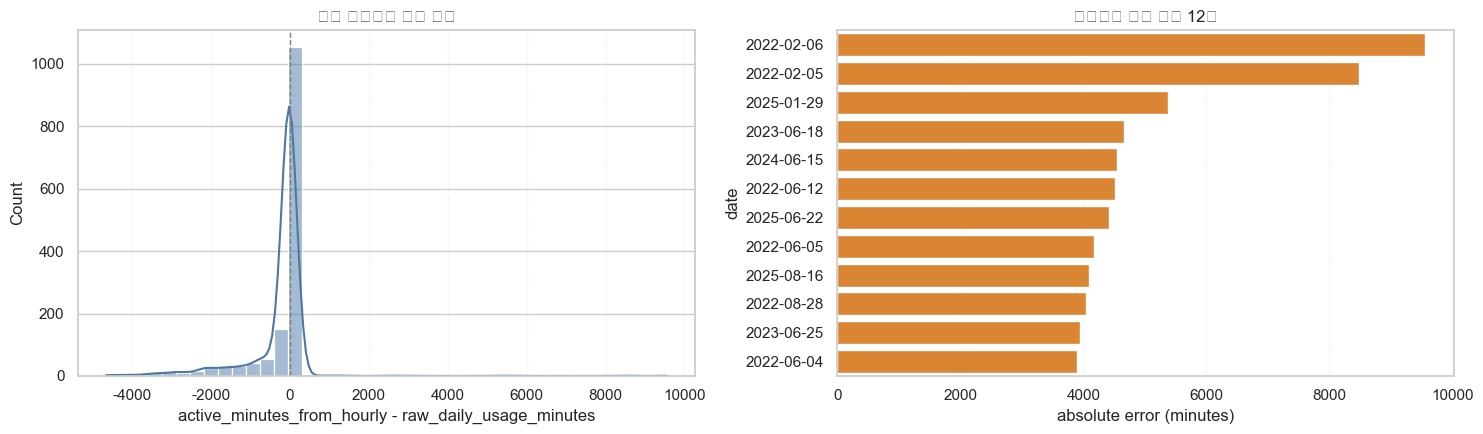

,날짜,raw_daily_parking_count,raw_daily_usage_minutes,active_minutes_from_hourly,usage_gap_minutes,usage_ape
36,2022-02-06,637,0,9555.000000,9555.000000,NaN
35,2022-02-05,1147,8725,17205.000000,8480.000000,0.971920
1118,2025-01-29,808,6738,12120.000000,5382.000000,0.798753
528,2023-06-18,3819,385582,380923.398631,-4658.601369,0.012082
890,2024-06-15,4097,398638,394087.315759,-4550.684241,0.011416
162,2022-06-12,2988,331115,326593.587982,-4521.412018,0.013655
1262,2025-06-22,2907,322514,318103.989190,-4410.010810,0.013674
155,2022-06-05,2693,301765,297590.507006,-4174.492994,0.013834
1317,2025-08-16,2622,294606,290517.834753,-4088.165247,0.013877
239,2022-08-28,4557,408972,404935.470597,-4036.529403,0.009870


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sns.histplot(merged["usage_gap_minutes"], bins=40, kde=True, ax=axes[0], color="#4C78A8")
axes[0].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("일별 이용시간 차이 분포")
axes[0].set_xlabel("active_minutes_from_hourly - raw_daily_usage_minutes")

top_gap = merged.nlargest(12, "usage_abs_error").copy()
sns.barplot(data=top_gap, x="usage_abs_error", y=top_gap["날짜"].dt.strftime("%Y-%m-%d"), ax=axes[1], color="#F58518")
axes[1].set_title("이용시간 차이 상위 12일")
axes[1].set_xlabel("absolute error (minutes)")
axes[1].set_ylabel("date")

for ax in axes:
    ax.grid(axis="x", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()

display(top_gap[["날짜", "raw_daily_parking_count", "raw_daily_usage_minutes", "active_minutes_from_hourly", "usage_gap_minutes", "usage_ape"]])


## 4. 최종 판단

이번 비교 결과를 종합하면 다음처럼 판단할 수 있습니다.

- `estimated_entries`는 일별 `주차대수`를 사실상 완벽하게 보존합니다.
- `estimated_active_cars`를 일별로 적분한 값도 원본 `이용시간`과 매우 높은 상관을 보이며, 대부분 날짜에서 차이가 매우 작습니다.
- 다만 일부 저이용 또는 특이 날짜에서는 상대오차가 크게 튀는 구간이 있습니다.
- 따라서 **난지 시간별 통합 데이터는 일별 원본 총량을 시간축으로 확장한 학습용 추정 데이터로서는 신뢰도가 높다**고 볼 수 있습니다.
- 하지만 이것은 어디까지나 **원본 일별 데이터와의 내적 일관성 검증**이므로, 실제 시간별 운영 상태를 직접 검증했다고 말할 수는 없습니다.

결론:

- 모델 학습용 시간별 추정 데이터로 사용: 적절
- 실제 시간별 운영 상황의 절대적 진실값으로 간주: 주의 필요
